In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)
%matplotlib inline

In [3]:
extract_path = "/content/drive/MyDrive/Wheat_Modified"
if os.path.exists(extract_path):
    print("Extracted files:", os.listdir(extract_path))
else:
    print("Extraction failed or path incorrect.")

Extracted files: ['Training', 'Testing', 'Validation']


In [4]:
for root, dirs, files in os.walk("/content/drive/MyDrive/Wheat_Modified"):
    print(root, dirs, files)

/content/drive/MyDrive/Wheat_Modified ['Training', 'Testing', 'Validation'] []
/content/drive/MyDrive/Wheat_Modified/Training ['Septoria', 'Stripe_rust', 'Healthy'] []
/content/drive/MyDrive/Wheat_Modified/Training/Septoria [] ['los(16).JPG', 'los(1).JPG', 'los(12).JPG', 'los(10).JPG', 'los(15).JPG', 'los(13).JPG', 'los(14).JPG', 'los(17).JPG', 'los(27).JPG', 'los(24).JPG', 'los(20).JPG', 'los(18).JPG', 'los(26).JPG', 'los(29).JPG', 'los(31).JPG', 'los(23).JPG', 'los(35).JPG', 'los(2).JPG', 'los(21).JPG', 'los(36).JPG', 'los(4).JPG', 'los(19).JPG', 'los(30).JPG', 'los(34).JPG', 'los(37).JPG', 'los(25).JPG', 'los(3).JPG', 'los(38).JPG', 'los(32).JPG', 'los(39).JPG', 'los(28).JPG', 'los(50).JPG', 'los(47).JPG', 'los(58).JPG', 'los(45).JPG', 'los(59).JPG', 'los(66).JPG', 'los(55).JPG', 'los(65).JPG', 'los(54).JPG', 'los(56).JPG', 'los(47) - Copy.JPG', 'los(68).JPG', 'los(62).JPG', 'los(42).JPG', 'los(41).JPG', 'los(67).JPG', 'los(57).JPG', 'los(46).JPG', 'los(64).JPG', 'los(5).JPG', 'los(

In [5]:
training_path='/content/drive/MyDrive/Wheat_Modified/Training'
validation_path='/content/drive/MyDrive/Wheat_Modified/Validation'
testing_path='/content/drive/MyDrive/Wheat_Modified/Testing'

In [6]:
print("Training path:", training_path)
print("Validation path:", validation_path)
print("Testing path:", testing_path)

Training path: /content/drive/MyDrive/Wheat_Modified/Training
Validation path: /content/drive/MyDrive/Wheat_Modified/Validation
Testing path: /content/drive/MyDrive/Wheat_Modified/Testing


In [7]:
train_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(training_path, target_size=(224,224), classes=['Healthy', 'Septoria', 'Stripe_rust'], batch_size=64)

valid_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(validation_path, target_size=(224,224), classes=['Healthy', 'Septoria', 'Stripe_rust'], batch_size=64)

test_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(testing_path, target_size=(224,224), classes=['Healthy', 'Septoria', 'Stripe_rust'], batch_size=64)

Found 240 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


In [8]:
# Preview a batch
x_batch, y_batch = next(train_batches)
print("Image shape:", x_batch.shape)
print("Pixel range (min to max):", x_batch.min(), "to", x_batch.max())


Image shape: (64, 224, 224, 3)
Pixel range (min to max): -123.68 to 151.061


In [9]:

# plots images with labels within jupyter notebook
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [10]:
imgs, labels = next(train_batches)

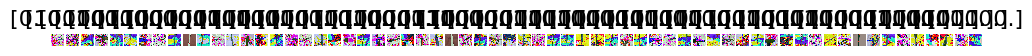

In [11]:
plots(imgs, titles=labels)

In [12]:
model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
        Flatten(),
        Dense(3, activation='softmax'),
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(Adam(learning_rate=0.1), loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor
    patience=20,             # Number of epochs to wait after no improvement
    verbose=1,              # Verbosity mode
    restore_best_weights=True # Restore the best weights after stopping
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1577088)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │     4,731,267 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,732,163 (18.05 MB)

 Trainable params: 4,732,163 (18.05 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.fit(train_batches, validation_data=valid_batches, epochs=500, callbacks=[early_stopping], verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/500
4/4 - 132s - 33s/step - accuracy: 0.2958 - loss: 2343239.0000 - val_accuracy: 0.3333 - val_loss: 1734011.3750
Epoch 2/500
4/4 - 35s - 9s/step - accuracy: 0.4458 - loss: 1073288.8750 - val_accuracy: 0.3333 - val_loss: 1476430.2500
Epoch 3/500
4/4 - 35s - 9s/step - accuracy: 0.5833 - loss: 801991.5625 - val_accuracy: 0.6667 - val_loss: 380300.8125
Epoch 4/500
4/4 - 34s - 9s/step - accuracy: 0.6750 - loss: 707795.0000 - val_accuracy: 0.5667 - val_loss: 775128.6875
Epoch 5/500
4/4 - 41s - 10s/step - accuracy: 0.7000 - loss: 738769.1250 - val_accuracy: 0.6000 - val_loss: 619001.3750
Epoch 6/500
4/4 - 33s - 8s/step - accuracy: 0.7542 - loss: 330930.8125 - val_accuracy: 0.4667 - val_loss: 619184.8125
Epoch 7/500
4/4 - 36s - 9s/step - accuracy: 0.8125 - loss: 301388.1562 - val_accuracy: 0.6333 - val_loss: 456784.0625
Epoch 8/500
4/4 - 34s - 9s/step - accuracy: 0.8917 - loss: 272433.1250 - val_accuracy: 0.7667 - val_loss: 442041.4688
Epoch 9/500
4/4 - 35s - 9s/step - accuracy: 0.937

In [17]:
print(f"Stopped at epoch: {early_stopping.stopped_epoch}")


Stopped at epoch: 32


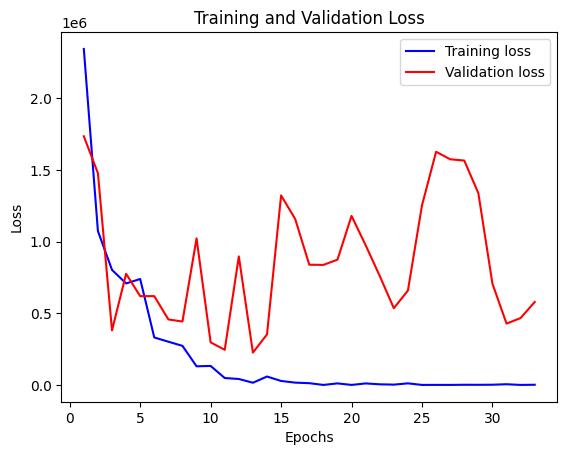

In [18]:
# prompt: plot training, testing and validation loss

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access the loss values
training_loss = model.history.history['loss']
validation_loss = model.history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(training_loss) + 1)  # Assuming epochs are available

plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


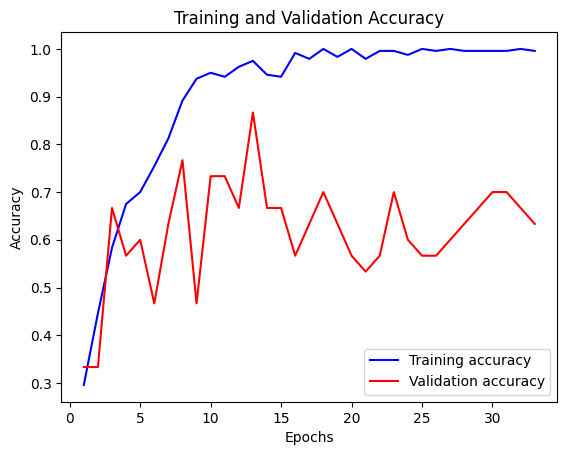

In [19]:
# Plot training and validation accuracy
training_accuracy = model.history.history['accuracy']
validation_accuracy = model.history.history['val_accuracy']

plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [20]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Training Loss: 35792.7773
Training Accuracy: 94.17%
Validation Loss: 225320.7188
Validation Accuracy: 86.67%
Test Loss: 1098662.0000
Test Accuracy: 53.33%


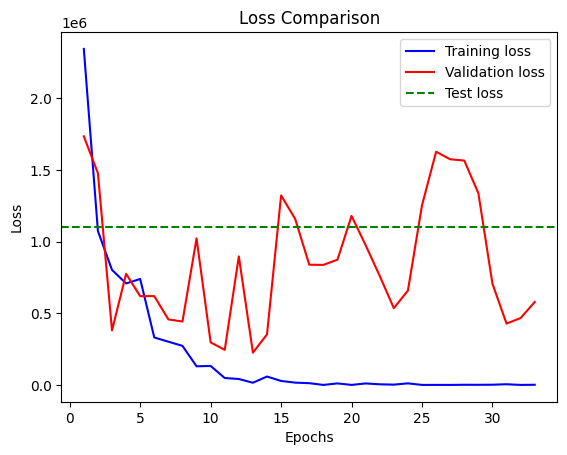

In [21]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

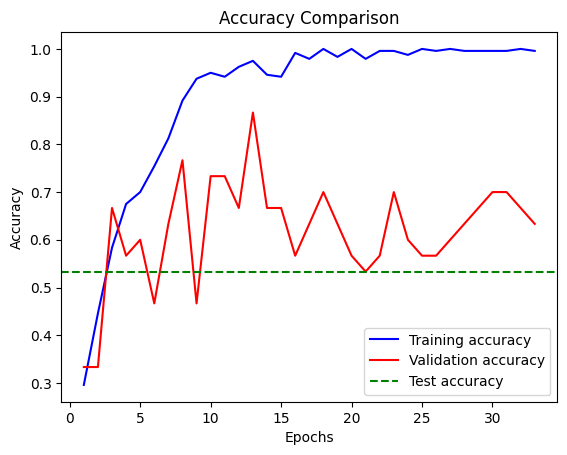

In [22]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [23]:
test_imgs, test_labels = next(test_batches)

# Get the model predictions
predictions = model.predict(test_imgs)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Print actual vs predicted labels (indices)
print(f"Actual labels: {test_labels}")
print(f"Predicted labels (indices): {predicted_classes}")

# Optionally, print the class names:
class_names = ['Healthy', 'Septoria', 'Stripe_rust']
predicted_class_names = [class_names[i] for i in predicted_classes]
print(f"Predicted class names: {predicted_class_names}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Actual labels: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
Predicted labels (indices): [1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 2 0 1 2 1 2 1 0 0 0 2 2 1 0 1]
Predicted class names: ['Septoria', 'Septoria', 'Healthy', 'Septoria', 'Healthy', 'Septoria', 'Healthy', 'Healthy', 'Septoria', 'Septoria', 'Septoria', 'Healthy', 'Septoria', 'Healthy', 'Septoria', 'Stripe_rust', 'Healthy', 'Septoria', 'Stripe_rust', 'Septoria', 'Stripe_rust', 'Septoria', 'Healthy', 'Healthy', 'Healthy', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Healthy', 'Septoria']


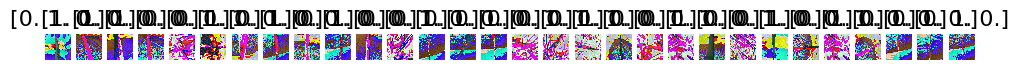

In [24]:
test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [25]:
test_labels = test_labels[:,0]
test_labels

array([0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.], dtype=float32)

In [26]:
predictions = model.predict(test_batches, steps=1, verbose=0)

In [27]:
predictions.round(2)

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], dtype=float32)

In [28]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

In [29]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [30]:
print("Training classes:", os.listdir(training_path))
print("Validation classes:", os.listdir(validation_path))
print("Testing classes:", os.listdir(testing_path))


Training classes: ['Septoria', 'Stripe_rust', 'Healthy']
Validation classes: ['Stripe_rust', 'Healthy', 'Septoria']
Testing classes: ['Healthy', 'Septoria', 'Stripe_rust']


Confusion matrix, without normalization
[[7 9 4]
 [4 5 1]
 [0 0 0]]


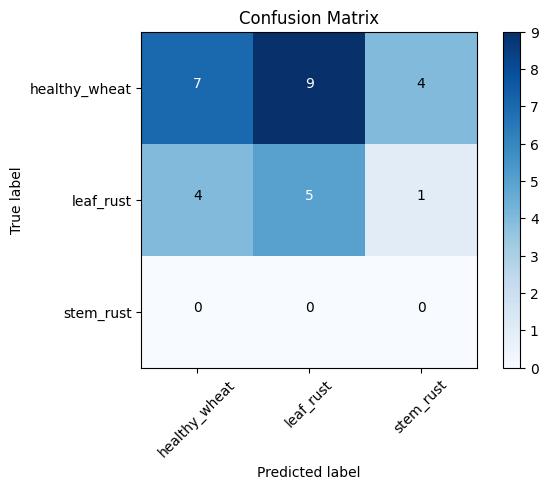

In [31]:
cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')